In [ ]:
# # PREDIKSI
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
# !cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
# !cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# # Data DBD
# DBD_df = pd.read_excel("data_kasus.xlsx", sheet_name="DBD")
# tahun_cols = [col for col in DBD_df.columns if str(col).isdigit()]
# DBD_df = DBD_df[["Nama Provinsi"] + tahun_cols]

# # Long format
# DBD_long = pd.melt(DBD_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
# DBD_long["Tahun"] = DBD_long["Tahun"].astype(int)
# DBD_long["Cases"] = pd.to_numeric(DBD_long["Cases"], errors='coerce')
# DBD_long = DBD_long[DBD_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# # DMI & ONI
# dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
# dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

# oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
# oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# # Folder untuk simpan grafik
# os.makedirs("plots", exist_ok=True)

# # Fungsi buat sequence
# def create_sequences(data, n_steps=3):
#     X, y = [], []
#     for i in range(len(data) - n_steps):
#         X.append(data[i:i+n_steps, 1:])  # input: DMI & ONI
#         y.append(data[i+n_steps, 0])     # target: Kasus
#     return np.array(X), np.array(y)
# provinces = DBD_long["Nama Provinsi"].unique()

# for province in provinces:
#     print(f"\nProcessing: {province}")
#     df = DBD_long[DBD_long["Nama Provinsi"] == province].copy()

#     # Gabungkan dengan DMI dan ONI
#     df = df.merge(dmi_df[["DMI"]], left_on="Tahun", right_index=True, how="left")
#     df = df.merge(oni_df[["ONI"]], left_on="Tahun", right_index=True, how="left")
#     df.dropna(inplace=True)

#     if len(df) < 5:
#         print(f"Skipping {province} due to insufficient data.")
#         continue

#     # Normalisasi
#     scaler = MinMaxScaler()
#     scaled = scaler.fit_transform(df[["Cases", "DMI", "ONI"]])
#     X, y = create_sequences(scaled, n_steps=3)

#     if len(X) < 1:
#         print(f"Skipping {province} due to insufficient sequences.")
#         continue
# # Train-test split
#     split = int(len(X) * 0.8)
#     X_train, X_test = X[:split], X[split:]
#     y_train, y_test = y[:split], y[split:]
#     n_features = X.shape[2]

#     # LSTM model
#     model = Sequential()
#     model.add(LSTM(8, return_sequences=True, input_shape=(3, n_features)))
#     model.add(Dropout(0.2))
#     model.add(LSTM(24, return_sequences=True))
#     model.add(Dropout(0.2))
#     model.add(LSTM(16, return_sequences=True))
#     model.add(Dropout(0.2))
#     model.add(LSTM(16, return_sequences=True))
#     model.add(Dropout(0.2))
#     model.add(LSTM(8))
#     model.add(Dropout(0.2))
#     model.add(Dense(1, activation='linear'))
#     model.compile(optimizer=Adam(), loss='mse')

#     model.fit(X_train, y_train, epochs=100, batch_size=4, verbose=0, validation_data=(X_test, y_test))

#     # Predict
#     y_pred = model.predict(X_test)

#     def inverse_scale(preds, features):
#         combined = np.concatenate((preds, features), axis=1)
#         return scaler.inverse_transform(combined)[:, 0]

#     y_test_inv = inverse_scale(y_test.reshape(-1, 1), X_test[:, -1])
#     y_pred_inv = inverse_scale(y_pred, X_test[:, -1])
#     # Save plot
#     plt.figure(figsize=(8, 4))
#     plt.plot(y_test_inv, label="Actual")
#     plt.plot(y_pred_inv, label="Predicted")
#     plt.title(f"DBD Prediction - {province}")
#     plt.xlabel("Tahun (relative index)")
#     plt.ylabel("Kasus Malaria")
#     plt.legend()
#     plt.grid()
#     plt.tight_layout()
#     filename = province.replace(" ", "_").replace("/", "_")
#     plt.savefig(f"plots/DBD_prediction_{filename}.png")
#     plt.close()

    # # Model LSTM
    # model = Sequential([
    #     LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    #     Dropout(0.2),
    #     Dense(1)
    # ])
    # model.compile(optimizer="adam", loss="mse")
    # model.fit(X, y, epochs=100, verbose=0)

    # # Prediksi
    # y_pred = model.predict(X)
    # actual = y
    # predicted = y_pred.flatten()

    # # Plot hasil
    # plt.figure(figsize=(10, 5))
    # plt.plot(actual, label="Actual", marker='o')
    # plt.plot(predicted, label="Predicted", marker='x')
    # plt.title(f"Prediksi Kasus Malaria: {province}")
    # plt.xlabel("Tahun (relative)")
    # plt.ylabel("Kasus (ter-normalisasi)")
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.savefig(f"plots/{province}_prediction.png")
    # plt.close()

# import os
# os.listdir("plots")


In [ ]:
# from IPython.display import Image, display
# display(Image("plots/DBD_prediction_MALUKU_UTARA.png"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: ACEH


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Final test loss for ACEH: 0.1130

Processing: SUMATERA UTARA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
Final test loss for SUMATERA UTARA: 0.1454

Processing: SUMATERA BARAT


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
Final test loss for MALUKU UTARA: 0.0809

Processing: PAPUA BARAT


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
Final test loss for PAPUA BARAT: 0.2457

Processing: PAPUA BARAT DAYA
Skipping PAPUA BARAT DAYA due to insufficient data.

Processing: PAPUA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
Final test loss for PAPUA: 0.0242

Processing: PAPUA SELATAN
Skipping PAPUA SELATAN due to insufficient data.

Processing: PAPUA TENGAH
Skipping PAPUA TENGAH due to insufficient data.

Processing: PAPUA PEGUNUNGAN
Skipping PAPUA PEGUNUNGAN due to insufficient data.

Performance Results Summary:
                Province Model   Train RMSE    Train MAE  Train R2  \
0                   ACEH   12H   504.769866   465.868515  0.256886   
1         SUMATERA UTARA   12H  1570.390095  1291.572771  0.152203   
2         SUMATERA BARAT   12H   573.593889   490.970944  0.537225   
3                   RIAU   12H  1288.778823  1065.733531 -0.225975   
4                  JAMBI   12H   590.197750   498.707810 -0.113601   
5       SUMATERA SELATAN   12H   727.073775   643.665706  0.271942   
6               BENGKULU   12H   422.317723   364.804400  0.107670   
7                LAMPUNG   12H   429.128351   331.459221  0.919691

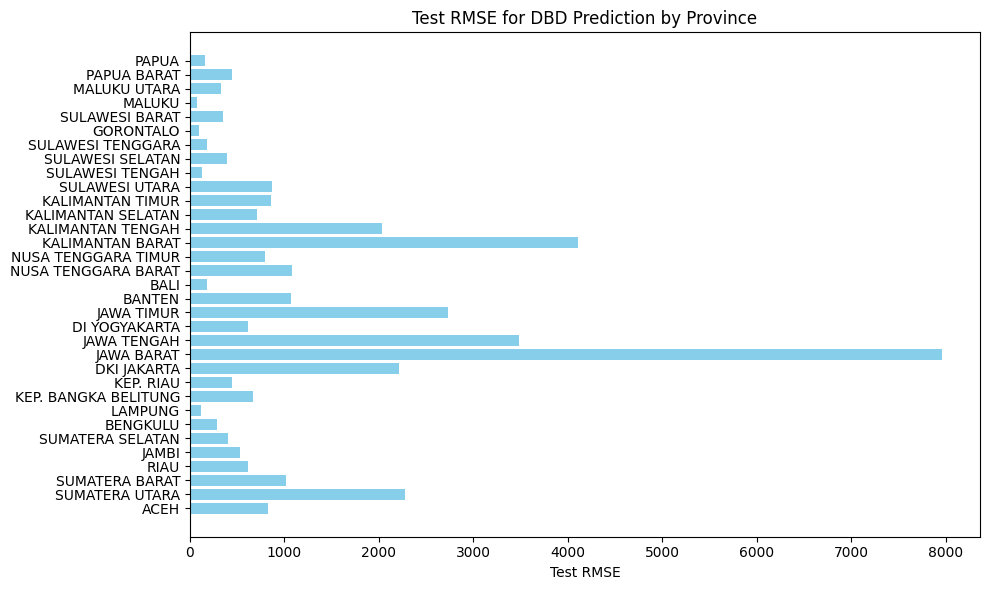

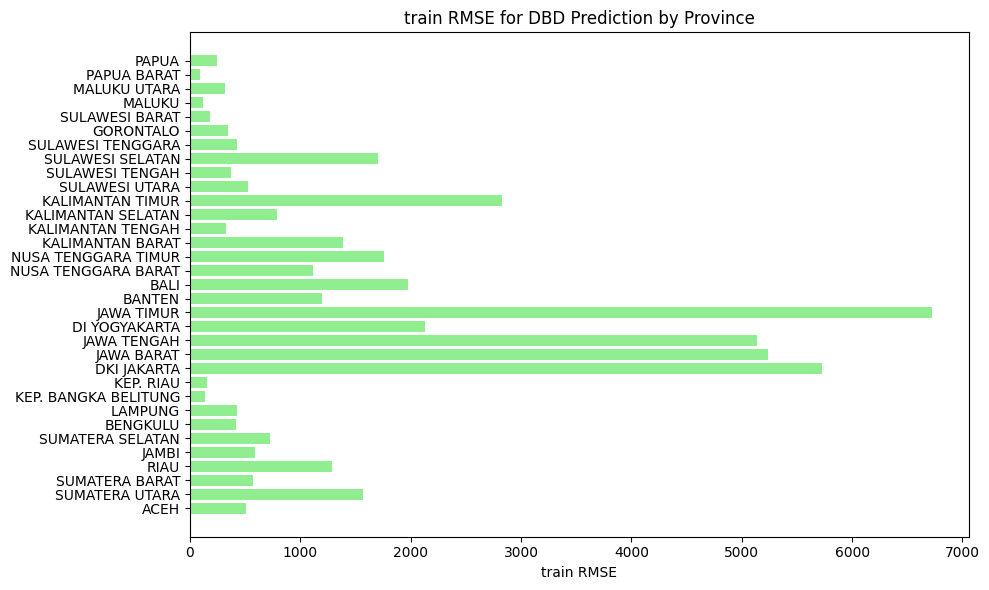

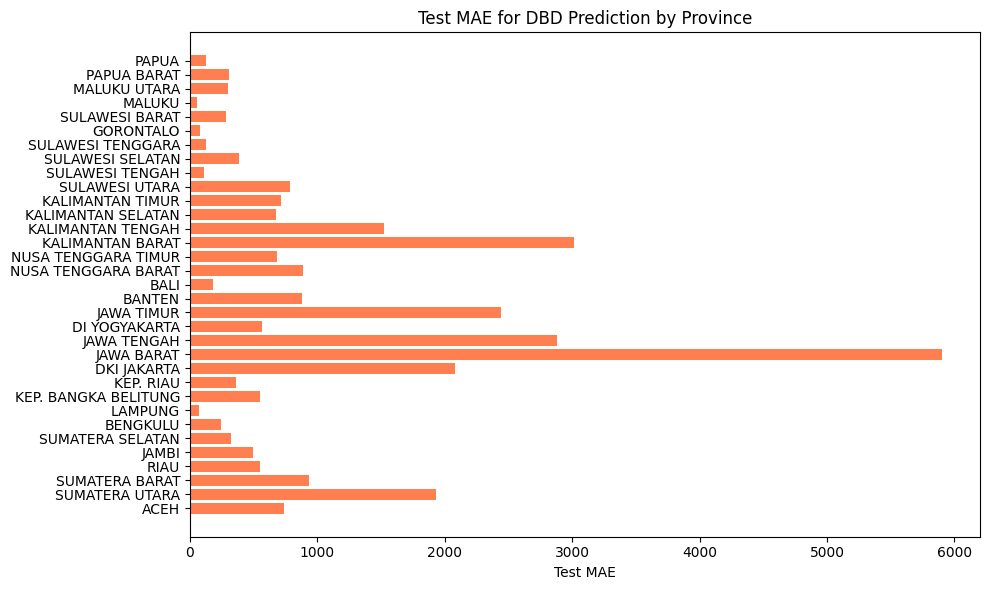

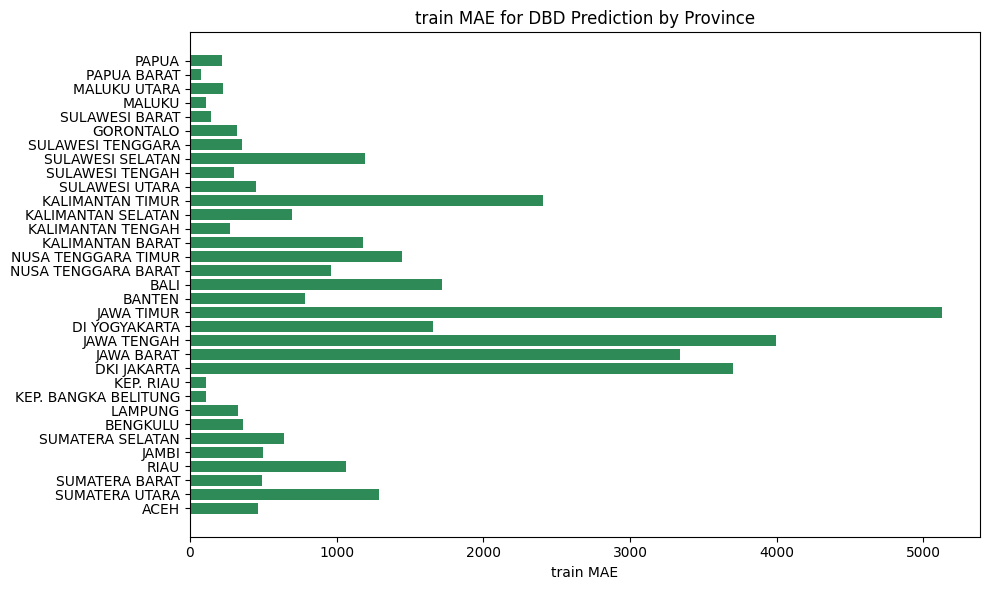

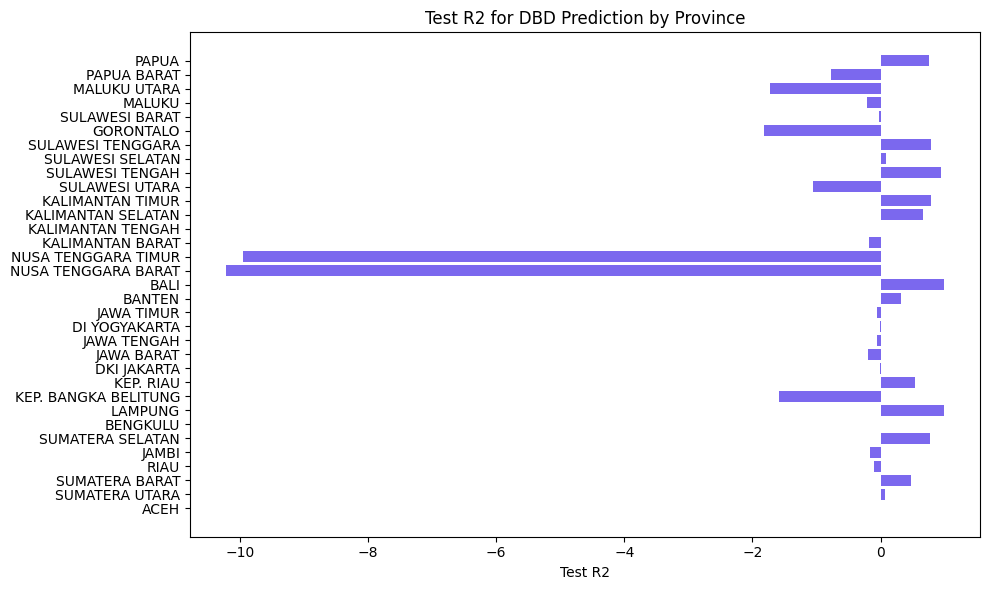

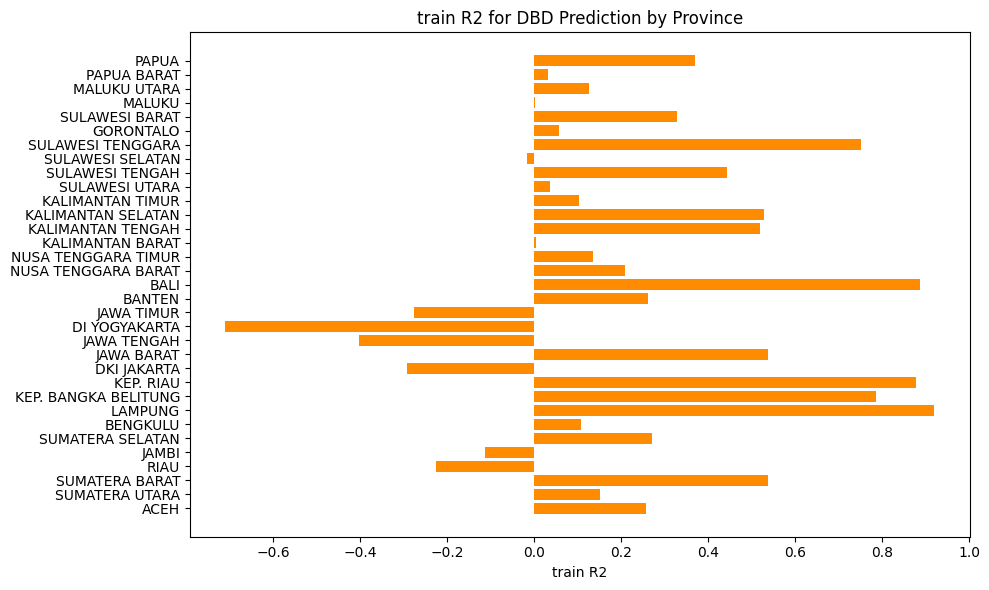

✅ Semua grafik model loss disimpan ke: /content/drive/MyDrive/DATA/plots_loss_DBD


In [ ]:
# LSTM, n_steps=1, batch size 2, epoch=300
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
!cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
!cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# Data DBD
DBD_df = pd.read_excel("data_kasus.xlsx", sheet_name="DBD")
tahun_cols = [col for col in DBD_df.columns if str(col).isdigit()]
DBD_df = DBD_df[["Nama Provinsi"] + tahun_cols]

# Long format
DBD_long = pd.melt(DBD_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
DBD_long["Tahun"] = DBD_long["Tahun"].astype(int)
DBD_long["Cases"] = pd.to_numeric(DBD_long["Cases"], errors='coerce')
DBD_long = DBD_long[DBD_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# DMI & ONI
dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# Folder untuk simpan grafik
os.makedirs("plots", exist_ok=True)

# Fungsi buat sequence
n_steps = 2
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # input: DMI & ONI(Ambil DMI&ONI sebagai input)
        y.append(data[i+n_steps, 0])     # target: Kasus(Target prediksi kasus pada waktu ke-(i+n_steps))
    return np.array(X), np.array(y)      # retun array input x dan target y
provinces = DBD_long["Nama Provinsi"].unique()    #mengambil daftar nama provinsi yang unik (tidak duplikat)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import pandas as pd

# Variabel untuk menyimpan metrik evaluasi (menyimpan evaluasi per provinsi)
performance_results = []

# Variabel untuk menyimpan history pelatihan tiap provinsi (loss/val_loss)
training_histories = {}

#loop untuk melatih dan mengevaluasi model LSTM di setiap provinsi
for province in provinces:
    print(f"\nProcessing: {province}")    #iterasi tiap provinsi
    df = DBD_long[DBD_long["Nama Provinsi"] == province].copy()   #Ambil data dari satu provinsi

    # Gabungkan dengan DMI dan ONI dan menghilangkan data NaN
    df = df.merge(dmi_df[["DMI"]], left_on="Tahun", right_index=True, how="left")
    df = df.merge(oni_df[["ONI"]], left_on="Tahun", right_index=True, how="left")
    df.dropna(inplace=True)

    if len(df) < 5:
        print(f"Skipping {province} due to insufficient data.")   #skip provinsi jika data terlalu sedikit
        continue

    # Normalisasi data agar nilai berada antara 0 dan 1
    scaler = MinMaxScaler()   #Menggunakan normalisasi min max scaling
    scaled = scaler.fit_transform(df[["Cases", "DMI", "ONI"]])    # Memilih 3 kolom (Cases, DMI, ONI) untuk dihitung nilai minimum dan maksimum dan mengubah nilai ke skala [0,1] dan hasilnya array scaled dengan 3 kolom
    X, y = create_sequences(scaled, n_steps=2)    # Bentuk data sekuens (X,y) untuk input LSTM

    # Tambahkan fungsi inverse_scale di sini: mengembalikan hasil prediksi ke skala aslinya (kasus DBD)
    def inverse_scale(preds, ref_features):   # Preds: Array hasil prediksi model, bentuknya (n_sample,1). tapi hanya berisi prediksi jumlah asus (kolom pertama dari data yang sebelumnya di normalisasi)
        dummy = np.zeros((len(preds), 2))   # Butuh menambahkan 3 kolom agar bisa memakai fungsi scaler.inverse_transform maka dibuat array dummy dengan bentuk (jumlah_data, 2) yang hanya berisi nol
        combined = np.hstack((preds, dummy))    # Menyatukan preds dengan dummy jadi bentuk [prediksi kasus, 0, 0] perbaris secara Horizontal agar struktur menyerupai data awal [Cases, DMI, ONI]
        return scaler.inverse_transform(combined)[:, 0]   # Membalik normalisasi ke skala asli, setelah di inverse_transform, ambil kolom pertama [:,0], yaitu hasil skala asli dari Cases
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")    #skip jika jumlah sequence terlalu sedikit untuk pelatihan
        continue

    # Train-test split
    split = int(len(X) * 0.8)   #split data training 80% dan testing 20%
    X_train, X_test = X[:split], X[split:]    # X[:split]: Ambil data dari awal sampai indeks ke 79 (data training); X[split:]: ambil data dari indeks ke-80 sampai akhir (data testing)
    y_train, y_test = y[:split], y[split:]    # sama seperti X, memisahkan label/target (y) ke data training dan testing dengan pembatas yang sama
    n_features = X.shape[2]   # Jumlah fitur (harus 2 = DMI & ONI)

    # LSTM model
    model = Sequential()    #membuat model bertipe Sequential (layer layer disusun secara berurutan dari input ke output)
    model.add(LSTM(8, return_sequences=True, input_shape=(n_steps, n_features)))    #layer pertama LSTM, 8: jumlah unit(neuron) dalam layer LSTM, return_sequences=true: mengembalikan urutan lengkap dari output, input_shape=(3,n_fearures): 3 (jumlah langah waktu/timesteps, karena mengambil 3 bulan sebelumnya), n_features(jumlah fitur per waktu (2 yaitu DMI dan ONI))
    model.add(Dropout(0.2))   # Dropout/teknik regulasi mematikan 20% neuron secara acak saat training agar model tidak overfitting
    # model.add(LSTM(8, return_sequences=True))        # LSTM terakhir dengan 8 unit tanpa return_sequence karena ini layer terakhir (hanya output akhir) yang dibutuhkan
    # model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(24, return_sequences=True))    # LSTM kedua dengan 24 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(16, return_sequences=True))    # LSTM ketiga dengan 16 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(16, return_sequences=True))    # LSTM Keempat dengan 16 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(8))        # LSTM terakhir dengan 8 unit tanpa return_sequence karena ini layer terakhir (hanya output akhir) yang dibutuhkan
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(Dense(1, activation='linear'))    # Output akhir adalah satu nilai kontinu (kasus DBD), jadi pake Dense(1); activation='linear': fungsi aktivasi linear (default), cocok untuk regresi (output bukan kategori)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')   # menyusuk (compile) model untuk siap dilatih dengan algoritma optimasi Adam yang adaptif untuk training deep learning; loss='mse': mse digunakan karena sedang melakukan regresi

    # Train model
    early_stop = EarlyStopping(monitor='val_loss', patience=550, restore_best_weights=True)
    history = model.fit(X_train, y_train,   # Hasilnya berupa objek history yg menyimpan nilai loss training dan loss validasi setiap epoch, Menggunakan model.fit untuk melatih model. X_train dan y_train adalah data input dan target untuk pelatihan
                        epochs=4000,         # Model dilatih selama 100 kali terhadap seluruh data training
                        batch_size=1,       # Data dibagi menjadi mini-batch berisi 4 sampel lalu di update per batch
                        verbose=0,          # Tidak menampilkan output di terminal saat training
                        callbacks=[early_stop],
                        validation_data=(X_test, y_test))     # Mengevalusi model setiap epoch untuk mengecek apakah model overfitting
    training_histories[province] = history.history  # simpan hasil History training (loss, val_loss) disimpan per provinsi

    # Predict on Train
    # Model dilatih dengan data yang dinormalisasi tapi hasilnya perlu dikembalikan ke bentuk kasus DBD nyata
    y_train_pred = model.predict(X_train)   # Model prediksi output (y) berdasarkan input training (X_train) hasilnya array prediksi yg nilainya masih terstandarisasi/ternormalisasi
    y_train_inv = inverse_scale(y_train.reshape(-1, 1), X_train[:, -1])   # Mengubah vektor 1D jadi array 2D agar cocok untuk inverse_scale yg mengubah nilai y_train kembali ke skala aslinya (jumlah kasus DBD asli) menggunakan MinMax scaler yang digunakan seelumnya. dan X_train[:, -1]: fitur terakhir dari setiap urutan waktu, hanya dipakai untuk mencocokan dimensi, tidak diproses dalam inverse_scale
    y_train_pred_inv = inverse_scale(y_train_pred, X_train[:, -1])    # Sama seperti baris sebelumnya tapi ini untuk , mengembalikan nilai presiksi hasil model ke skala aslinya

    # Predict on Test
    y_test_pred = model.predict(X_test)     # Model membuat prediksi terhadap data uji (X_test) hasilnya dalam bentuk skala normalisasi
    y_test_inv = inverse_scale(y_test.reshape(-1, 1), X_test[:, -1])     # Mengembalikan target y_test ke skala aslinya agar bisa dibandingkan dengan prediksi hasil model
    y_test_pred_inv = inverse_scale(y_test_pred, X_test[:, -1])    # Mengembalikan hasil prediksi dari model pada data test ke skala aslinya

    # Calculate performance metrics untuk training dan testing
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))   # Menghitung RMSE untuk data training. RMSE mengukur seberapa besar kesalahan prediksi model dalam satuan asli (jumlah kasus DBD)
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)              # Menghitung MAE (rata rata selisis absolut antara prediksi dan data asli)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))      # Menghitung RMSE untuk data testing
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)                 # Menghitung MAE untuk data testing
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)                          # Menghitung R squares (koefisien determinasi) untuk data training
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)                             # Menghitung R squares untuk data testing

    # Simpan hasil evaluasi per provinsi
    performance_results.append({
        'Province': province,
        'Model': '12H',  # This can be adjusted based on the model setup
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })
    # ⬇️ Tambahkan ini di akhir loop provinsi
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final test loss for {province}: {test_loss:.4f}")

performance_df = pd.DataFrame(performance_results)
performance_df.to_csv('performance_results_DBD DMI ONI_5layer_provinces.csv', index=False)
print("\nPerformance Results Summary:")
print(performance_df)

# summary plot (RMSE test comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test RMSE'], color='skyblue')
plt.xlabel('Test RMSE')
plt.title('Test RMSE for DBD Prediction by Province')
plt.tight_layout()
plt.savefig('plots/test_rmse_by_province.png')
plt.show()

# Summary plot (RMSE train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train RMSE'], color='Lightgreen')
plt.xlabel('train RMSE')
plt.title('train RMSE for DBD Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_rmse_by_province.png')
plt.show()

# Summary plot (MAE test comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test MAE'], color='coral')
plt.xlabel('Test MAE')
plt.title('Test MAE for DBD Prediction by Province')
plt.tight_layout()
plt.savefig('plots/test_mae_by_province.png')
plt.show()

# Summary plot (MAE train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train MAE'], color='seagreen')
plt.xlabel('train MAE')
plt.title('train MAE for DBD Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_mae_by_province.png')
plt.show()

# Summary plot (R2 test comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test R2'], color='mediumslateblue')
plt.xlabel('Test R2')
plt.title('Test R2 for DBD Prediction by Province')
plt.tight_layout()
plt.savefig('plots/test_R2_by_province.png')
plt.show()

# Summary plot (R2 train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train R2'], color='darkorange')
plt.xlabel('train R2')
plt.title('train R2 for DBD Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_R2_by_province.png')
plt.show()

import matplotlib.pyplot as plt
import os

# Pastikan folder penyimpanan ada
drive_output_dir = "/content/drive/MyDrive/DATA/plots_loss_DBD"
os.makedirs(drive_output_dir, exist_ok=True)

# Loop untuk setiap provinsi yang ada di training_histories
for prov, hist in training_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Validation')
    plt.title(f"Model loss - {prov}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Buat nama file yang rapi
    filename = prov.replace(" ", "_").replace("/", "_")
    path = os.path.join(drive_output_dir, f"loss_{filename}.png")
    plt.savefig(path)
    plt.close()

print(f"✅ Semua grafik model loss disimpan ke: {drive_output_dir}")


In [ ]:
print (test_r2)
print (y_test_pred_inv)
print (y_test_inv)

-2.307373576921369
[404.68880343 446.84100413]
[533. 897.]


In [ ]:
# import matplotlib.pyplot as plt
# import os

# # Pastikan folder penyimpanan ada
# drive_output_dir = "/content/drive/MyDrive/DATA/plots_loss_DBD"
# os.makedirs(drive_output_dir, exist_ok=True)

# # Loop untuk setiap provinsi yang ada di training_histories
# for prov, hist in training_histories.items():
#     plt.figure(figsize=(6, 4))
#     plt.plot(hist['loss'], label='Train')
#     plt.plot(hist['val_loss'], label='Validation')
#     plt.title(f"Model loss - {prov}")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss (MSE)")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()

#     # Buat nama file yang rapi
#     filename = prov.replace(" ", "_").replace("/", "_")
#     path = os.path.join(drive_output_dir, f"loss_{filename}.png")
#     plt.savefig(path)
#     plt.close()

# print(f"✅ Semua grafik model loss disimpan ke: {drive_output_dir}")


NameError: name 'training_histories' is not defined

In [ ]:
# LSTM, n_steps=1, batch size 2, epoch=300
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
!cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
!cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# Data DBD
DBD_df = pd.read_excel("data_kasus.xlsx", sheet_name="DBD")
tahun_cols = [col for col in DBD_df.columns if str(col).isdigit()]
DBD_df = DBD_df[["Nama Provinsi"] + tahun_cols]

# Long format
DBD_long = pd.melt(DBD_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
DBD_long["Tahun"] = DBD_long["Tahun"].astype(int)
DBD_long["Cases"] = pd.to_numeric(DBD_long["Cases"], errors='coerce')
DBD_long = DBD_long[DBD_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# DMI & ONI
dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# Folder untuk simpan grafik
os.makedirs("plots", exist_ok=True)

# Fungsi buat sequence
n_steps = 2
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # input: DMI & ONI(Ambil DMI&ONI sebagai input)
        y.append(data[i+n_steps, 0])     # target: Kasus(Target prediksi kasus pada waktu ke-(i+n_steps))
    return np.array(X), np.array(y)      # retun array input x dan target y
provinces = DBD_long["Nama Provinsi"].unique()    #mengambil daftar nama provinsi yang unik (tidak duplikat)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import pandas as pd

# Variabel untuk menyimpan metrik evaluasi (menyimpan evaluasi per provinsi)
performance_results = []

# Variabel untuk menyimpan history pelatihan tiap provinsi (loss/val_loss)
training_histories = {}

#loop untuk melatih dan mengevaluasi model LSTM di setiap provinsi
for province in provinces:
  if province == "NUSA TENGGARA BARAT"or province == "NUSA TENGGARA TIMUR":
    print(f"\nProcessing: {province}")    #iterasi tiap provinsi
    df = DBD_long[DBD_long["Nama Provinsi"] == province].copy()   #Ambil data dari satu provinsi

    # Gabungkan dengan DMI dan ONI dan menghilangkan data NaN
    df = df.merge(dmi_df[["DMI"]], left_on="Tahun", right_index=True, how="left")
    df = df.merge(oni_df[["ONI"]], left_on="Tahun", right_index=True, how="left")
    df.dropna(inplace=True)

    if len(df) < 5:
        print(f"Skipping {province} due to insufficient data.")   #skip provinsi jika data terlalu sedikit
        continue

    # Normalisasi data agar nilai berada antara 0 dan 1
    scaler = MinMaxScaler()   #Menggunakan normalisasi min max scaling
    scaled = scaler.fit_transform(df[["Cases", "DMI", "ONI"]])    # Memilih 3 kolom (Cases, DMI, ONI) untuk dihitung nilai minimum dan maksimum dan mengubah nilai ke skala [0,1] dan hasilnya array scaled dengan 3 kolom
    X, y = create_sequences(scaled, n_steps=2)    # Bentuk data sekuens (X,y) untuk input LSTM

    # Tambahkan fungsi inverse_scale di sini: mengembalikan hasil prediksi ke skala aslinya (kasus DBD)
    def inverse_scale(preds, ref_features):   # Preds: Array hasil prediksi model, bentuknya (n_sample,1). tapi hanya berisi prediksi jumlah asus (kolom pertama dari data yang sebelumnya di normalisasi)
        dummy = np.zeros((len(preds), 2))   # Butuh menambahkan 3 kolom agar bisa memakai fungsi scaler.inverse_transform maka dibuat array dummy dengan bentuk (jumlah_data, 2) yang hanya berisi nol
        combined = np.hstack((preds, dummy))    # Menyatukan preds dengan dummy jadi bentuk [prediksi kasus, 0, 0] perbaris secara Horizontal agar struktur menyerupai data awal [Cases, DMI, ONI]
        return scaler.inverse_transform(combined)[:, 0]   # Membalik normalisasi ke skala asli, setelah di inverse_transform, ambil kolom pertama [:,0], yaitu hasil skala asli dari Cases
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")    #skip jika jumlah sequence terlalu sedikit untuk pelatihan
        continue

    # Train-test split
    split = int(len(X) * 0.8)   #split data training 80% dan testing 20%
    X_train, X_test = X[:split], X[split:]    # X[:split]: Ambil data dari awal sampai indeks ke 79 (data training); X[split:]: ambil data dari indeks ke-80 sampai akhir (data testing)
    y_train, y_test = y[:split], y[split:]    # sama seperti X, memisahkan label/target (y) ke data training dan testing dengan pembatas yang sama
    n_features = X.shape[2]   # Jumlah fitur (harus 2 = DMI & ONI)

    # LSTM model
    model = Sequential()    #membuat model bertipe Sequential (layer layer disusun secara berurutan dari input ke output)
    model.add(LSTM(8, return_sequences=True, input_shape=(n_steps, n_features)))    #layer pertama LSTM, 8: jumlah unit(neuron) dalam layer LSTM, return_sequences=true: mengembalikan urutan lengkap dari output, input_shape=(3,n_fearures): 3 (jumlah langah waktu/timesteps, karena mengambil 3 bulan sebelumnya), n_features(jumlah fitur per waktu (2 yaitu DMI dan ONI))
    model.add(Dropout(0.2))   # Dropout/teknik regulasi mematikan 20% neuron secara acak saat training agar model tidak overfitting
    # model.add(LSTM(8, return_sequences=True))        # LSTM terakhir dengan 8 unit tanpa return_sequence karena ini layer terakhir (hanya output akhir) yang dibutuhkan
    # model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(16, return_sequences=True))    # LSTM kedua dengan 24 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(12, return_sequences=True))    # LSTM ketiga dengan 16 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(12, return_sequences=True))    # LSTM Keempat dengan 16 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(2))        # LSTM terakhir dengan 8 unit tanpa return_sequence karena ini layer terakhir (hanya output akhir) yang dibutuhkan
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(Dense(1, activation='linear'))    # Output akhir adalah satu nilai kontinu (kasus DBD), jadi pake Dense(1); activation='linear': fungsi aktivasi linear (default), cocok untuk regresi (output bukan kategori)
    model.compile(optimizer=Adam(learning_rate=0.09), loss='mse')   # menyusuk (compile) model untuk siap dilatih dengan algoritma optimasi Adam yang adaptif untuk training deep learning; loss='mse': mse digunakan karena sedang melakukan regresi

    # Train model
    early_stop = EarlyStopping(monitor='val_loss', patience=700, restore_best_weights=True)
    history = model.fit(X_train, y_train,   # Hasilnya berupa objek history yg menyimpan nilai loss training dan loss validasi setiap epoch, Menggunakan model.fit untuk melatih model. X_train dan y_train adalah data input dan target untuk pelatihan
                        epochs=4000,         # Model dilatih selama 100 kali terhadap seluruh data training
                        batch_size=1,       # Data dibagi menjadi mini-batch berisi 4 sampel lalu di update per batch
                        verbose=0,          # Tidak menampilkan output di terminal saat training
                        callbacks=[early_stop],
                        validation_data=(X_test, y_test))     # Mengevalusi model setiap epoch untuk mengecek apakah model overfitting
    training_histories[province] = history.history  # simpan hasil History training (loss, val_loss) disimpan per provinsi

    # Predict on Train
    # Model dilatih dengan data yang dinormalisasi tapi hasilnya perlu dikembalikan ke bentuk kasus DBD nyata
    y_train_pred = model.predict(X_train)   # Model prediksi output (y) berdasarkan input training (X_train) hasilnya array prediksi yg nilainya masih terstandarisasi/ternormalisasi
    y_train_inv = inverse_scale(y_train.reshape(-1, 1), X_train[:, -1])   # Mengubah vektor 1D jadi array 2D agar cocok untuk inverse_scale yg mengubah nilai y_train kembali ke skala aslinya (jumlah kasus DBD asli) menggunakan MinMax scaler yang digunakan seelumnya. dan X_train[:, -1]: fitur terakhir dari setiap urutan waktu, hanya dipakai untuk mencocokan dimensi, tidak diproses dalam inverse_scale
    y_train_pred_inv = inverse_scale(y_train_pred, X_train[:, -1])    # Sama seperti baris sebelumnya tapi ini untuk , mengembalikan nilai presiksi hasil model ke skala aslinya

    # Predict on Test
    y_test_pred = model.predict(X_test)     # Model membuat prediksi terhadap data uji (X_test) hasilnya dalam bentuk skala normalisasi
    y_test_inv = inverse_scale(y_test.reshape(-1, 1), X_test[:, -1])     # Mengembalikan target y_test ke skala aslinya agar bisa dibandingkan dengan prediksi hasil model
    y_test_pred_inv = inverse_scale(y_test_pred, X_test[:, -1])    # Mengembalikan hasil prediksi dari model pada data test ke skala aslinya

    # Calculate performance metrics untuk training dan testing
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))   # Menghitung RMSE untuk data training. RMSE mengukur seberapa besar kesalahan prediksi model dalam satuan asli (jumlah kasus DBD)
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)              # Menghitung MAE (rata rata selisis absolut antara prediksi dan data asli)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))      # Menghitung RMSE untuk data testing
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)                 # Menghitung MAE untuk data testing
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)                          # Menghitung R squares (koefisien determinasi) untuk data training
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)                             # Menghitung R squares untuk data testing

    # Simpan hasil evaluasi per provinsi
    performance_results.append({
        'Province': province,
        'Model': '12H',  # This can be adjusted based on the model setup
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })
    # ⬇️ Tambahkan ini di akhir loop provinsi
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final test loss for {province}: {test_loss:.4f}")
# Convert performance results to DataFrame
performance_df = pd.DataFrame(performance_results)

# Save to CSV for further analysis
# performance_df.to_csv('performance_DBD_results_provinces.csv', index=False)

# Print performance summary in table format
print("\nPerformance Results DBD Summary:")
print(performance_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: NUSA TENGGARA BARAT


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
Final test loss for NUSA TENGGARA BARAT: 0.0329

Processing: NUSA TENGGARA TIMUR


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
Final test loss for NUSA TENGGARA TIMUR: 0.0039

Performance Results DBD Summary:
              Province Model   Train RMSE    Train MAE  Train R2   Test RMSE  \
0  NUSA TENGGARA BARAT   12H  1360.691802  1197.478594 -0.184386  774.204958   
1  NUSA TENGGARA TIMUR   12H  2071.557793  1963.066358 -0.197907  362.529808   

     Test MAE   Test R2  
0  703.897550 -4.767748  
1  271.213888 -1.271053  


Mounted at /content/drive

Processing: MALUKU


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step    
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
Final test loss for MALUKU: 0.0367

Performance Results DBD Summary:
  Province Model  Train RMSE   Train MAE  Train R2  Test RMSE   Test MAE  \
0   MALUKU   12H  122.399993  114.940346 -0.044543  68.345949  56.973753   

    Test R2  
0 -0.012195  


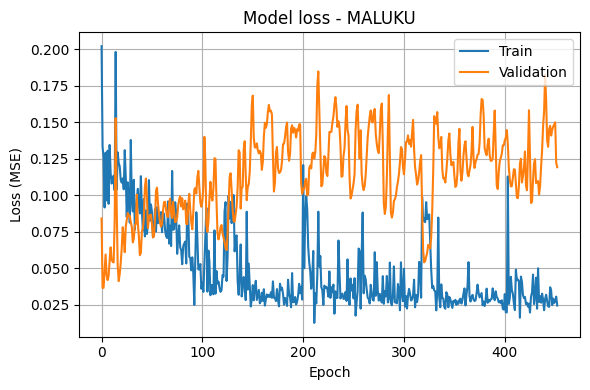

In [ ]:
# LSTM, n_steps=1, batch size 2, epoch=300
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import os
import random
import numpy as np
import tensorflow as tf

def set_seeds(seed=23):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(23)

from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
!cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
!cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# Data DBD
DBD_df = pd.read_excel("data_kasus.xlsx", sheet_name="DBD")
tahun_cols = [col for col in DBD_df.columns if str(col).isdigit()]
DBD_df = DBD_df[["Nama Provinsi"] + tahun_cols]

# Long format
DBD_long = pd.melt(DBD_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
DBD_long["Tahun"] = DBD_long["Tahun"].astype(int)
DBD_long["Cases"] = pd.to_numeric(DBD_long["Cases"], errors='coerce')
DBD_long = DBD_long[DBD_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# DMI & ONI
dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# Folder untuk simpan grafik
os.makedirs("plots", exist_ok=True)

# Fungsi buat sequence
n_steps = 2
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # input: DMI & ONI(Ambil DMI&ONI sebagai input)
        y.append(data[i+n_steps, 0])     # target: Kasus(Target prediksi kasus pada waktu ke-(i+n_steps))
    return np.array(X), np.array(y)      # retun array input x dan target y
provinces = DBD_long["Nama Provinsi"].unique()    #mengambil daftar nama provinsi yang unik (tidak duplikat)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import pandas as pd

# Variabel untuk menyimpan metrik evaluasi (menyimpan evaluasi per provinsi)
performance_results = []

# Variabel untuk menyimpan history pelatihan tiap provinsi (loss/val_loss)
training_histories = {}

#loop untuk melatih dan mengevaluasi model LSTM di setiap provinsi
for province in provinces:
  if province == "MALUKU":
    print(f"\nProcessing: {province}")    #iterasi tiap provinsi
    df = DBD_long[DBD_long["Nama Provinsi"] == province].copy()   #Ambil data dari satu provinsi

    # Gabungkan dengan DMI dan ONI dan menghilangkan data NaN
    df = df.merge(dmi_df[["DMI"]], left_on="Tahun", right_index=True, how="left")
    df = df.merge(oni_df[["ONI"]], left_on="Tahun", right_index=True, how="left")
    df.dropna(inplace=True)

    if len(df) < 5:
        print(f"Skipping {province} due to insufficient data.")   #skip provinsi jika data terlalu sedikit
        continue

    # Normalisasi data agar nilai berada antara 0 dan 1
    scaler = MinMaxScaler()   #Menggunakan normalisasi min max scaling
    scaled = scaler.fit_transform(df[["Cases", "DMI", "ONI"]])    # Memilih 3 kolom (Cases, DMI, ONI) untuk dihitung nilai minimum dan maksimum dan mengubah nilai ke skala [0,1] dan hasilnya array scaled dengan 3 kolom
    X, y = create_sequences(scaled, n_steps=2)    # Bentuk data sekuens (X,y) untuk input LSTM

    # Tambahkan fungsi inverse_scale di sini: mengembalikan hasil prediksi ke skala aslinya (kasus DBD)
    def inverse_scale(preds, ref_features):   # Preds: Array hasil prediksi model, bentuknya (n_sample,1). tapi hanya berisi prediksi jumlah asus (kolom pertama dari data yang sebelumnya di normalisasi)
        dummy = np.zeros((len(preds), 2))   # Butuh menambahkan 3 kolom agar bisa memakai fungsi scaler.inverse_transform maka dibuat array dummy dengan bentuk (jumlah_data, 2) yang hanya berisi nol
        combined = np.hstack((preds, dummy))    # Menyatukan preds dengan dummy jadi bentuk [prediksi kasus, 0, 0] perbaris secara Horizontal agar struktur menyerupai data awal [Cases, DMI, ONI]
        return scaler.inverse_transform(combined)[:, 0]   # Membalik normalisasi ke skala asli, setelah di inverse_transform, ambil kolom pertama [:,0], yaitu hasil skala asli dari Cases
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")    #skip jika jumlah sequence terlalu sedikit untuk pelatihan
        continue

    # Train-test split
    split = int(len(X) * 0.8)   #split data training 80% dan testing 20%
    X_train, X_test = X[:split], X[split:]    # X[:split]: Ambil data dari awal sampai indeks ke 79 (data training); X[split:]: ambil data dari indeks ke-80 sampai akhir (data testing)
    y_train, y_test = y[:split], y[split:]    # sama seperti X, memisahkan label/target (y) ke data training dan testing dengan pembatas yang sama
    n_features = X.shape[2]   # Jumlah fitur (harus 2 = DMI & ONI)

    # LSTM model
    model = Sequential()    #membuat model bertipe Sequential (layer layer disusun secara berurutan dari input ke output)
    model.add(LSTM(8, return_sequences=True, input_shape=(n_steps, n_features)))    #layer pertama LSTM, 8: jumlah unit(neuron) dalam layer LSTM, return_sequences=true: mengembalikan urutan lengkap dari output, input_shape=(3,n_fearures): 3 (jumlah langah waktu/timesteps, karena mengambil 3 bulan sebelumnya), n_features(jumlah fitur per waktu (2 yaitu DMI dan ONI))
    model.add(Dropout(0.2))   # Dropout/teknik regulasi mematikan 20% neuron secara acak saat training agar model tidak overfitting
    # model.add(LSTM(8, return_sequences=True))        # LSTM terakhir dengan 8 unit tanpa return_sequence karena ini layer terakhir (hanya output akhir) yang dibutuhkan
    # model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(24, return_sequences=True))    # LSTM kedua dengan 24 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(16, return_sequences=True))    # LSTM ketiga dengan 16 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(16, return_sequences=True))    # LSTM Keempat dengan 16 unit dan masih mengembalikan semua urutan ke layer selanjutnya
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(LSTM(8))        # LSTM terakhir dengan 8 unit tanpa return_sequence karena ini layer terakhir (hanya output akhir) yang dibutuhkan
    model.add(Dropout(0.2))   # Dropout mencegah overfitting
    model.add(Dense(1, activation='linear'))    # Output akhir adalah satu nilai kontinu (kasus DBD), jadi pake Dense(1); activation='linear': fungsi aktivasi linear (default), cocok untuk regresi (output bukan kategori)
    model.compile(optimizer=Adam(learning_rate=0.0095), loss='mse')   # menyusuk (compile) model untuk siap dilatih dengan algoritma optimasi Adam yang adaptif untuk training deep learning; loss='mse': mse digunakan karena sedang melakukan regresi

    # Train model
    early_stop = EarlyStopping(monitor='val_loss', patience=450, restore_best_weights=True)
    history = model.fit(X_train, y_train,   # Hasilnya berupa objek history yg menyimpan nilai loss training dan loss validasi setiap epoch, Menggunakan model.fit untuk melatih model. X_train dan y_train adalah data input dan target untuk pelatihan
                        epochs=4000,         # Model dilatih selama 100 kali terhadap seluruh data training
                        batch_size=1,       # Data dibagi menjadi mini-batch berisi 4 sampel lalu di update per batch
                        verbose=0,          # Tidak menampilkan output di terminal saat training
                        callbacks=[early_stop],
                        validation_data=(X_test, y_test))     # Mengevalusi model setiap epoch untuk mengecek apakah model overfitting
    training_histories[province] = history.history  # simpan hasil History training (loss, val_loss) disimpan per provinsi

    # Predict on Train
    # Model dilatih dengan data yang dinormalisasi tapi hasilnya perlu dikembalikan ke bentuk kasus DBD nyata
    y_train_pred = model.predict(X_train)   # Model prediksi output (y) berdasarkan input training (X_train) hasilnya array prediksi yg nilainya masih terstandarisasi/ternormalisasi
    y_train_inv = inverse_scale(y_train.reshape(-1, 1), X_train[:, -1])   # Mengubah vektor 1D jadi array 2D agar cocok untuk inverse_scale yg mengubah nilai y_train kembali ke skala aslinya (jumlah kasus DBD asli) menggunakan MinMax scaler yang digunakan seelumnya. dan X_train[:, -1]: fitur terakhir dari setiap urutan waktu, hanya dipakai untuk mencocokan dimensi, tidak diproses dalam inverse_scale
    y_train_pred_inv = inverse_scale(y_train_pred, X_train[:, -1])    # Sama seperti baris sebelumnya tapi ini untuk , mengembalikan nilai presiksi hasil model ke skala aslinya

    # Predict on Test
    y_test_pred = model.predict(X_test)     # Model membuat prediksi terhadap data uji (X_test) hasilnya dalam bentuk skala normalisasi
    y_test_inv = inverse_scale(y_test.reshape(-1, 1), X_test[:, -1])     # Mengembalikan target y_test ke skala aslinya agar bisa dibandingkan dengan prediksi hasil model
    y_test_pred_inv = inverse_scale(y_test_pred, X_test[:, -1])    # Mengembalikan hasil prediksi dari model pada data test ke skala aslinya

    # Calculate performance metrics untuk training dan testing
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))   # Menghitung RMSE untuk data training. RMSE mengukur seberapa besar kesalahan prediksi model dalam satuan asli (jumlah kasus DBD)
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)              # Menghitung MAE (rata rata selisis absolut antara prediksi dan data asli)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))      # Menghitung RMSE untuk data testing
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)                 # Menghitung MAE untuk data testing
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)                          # Menghitung R squares (koefisien determinasi) untuk data training
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)                             # Menghitung R squares untuk data testing

    # Simpan hasil evaluasi per provinsi
    performance_results.append({
        'Province': province,
        'Model': '12H',  # This can be adjusted based on the model setup
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })
    # ⬇️ Tambahkan ini di akhir loop provinsi
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final test loss for {province}: {test_loss:.4f}")
# Convert performance results to DataFrame
performance_df = pd.DataFrame(performance_results)

# Save to CSV for further analysis
# performance_df.to_csv('performance_DBD_results_provinces.csv', index=False)

# Print performance summary in table format
print("\nPerformance Results DBD Summary:")
print(performance_df)

# Loop untuk setiap provinsi yang ada di training_histories
for prov, hist in training_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Validation')
    plt.title(f"Model loss - {prov}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Tampilkan plot
    plt.show()
